In [1]:
import pandas as pd

In [30]:
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_jan_21 = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2021-01.parquet")


In [4]:
df_feb_21 = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2021-02.parquet")


In [10]:
df_jan_21.tpep_dropoff_datetime = pd.to_datetime(df_jan_21.tpep_dropoff_datetime)

In [13]:
df_jan_21.tpep_pickup_datetime = pd.to_datetime(df_jan_21.tpep_pickup_datetime)

In [14]:
df_jan_21.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2021-01-01 00:30:10,2021-01-01 00:36:12,1.0,2.10,1.0,N,142,43,2,8.0,3.0,0.5,0.00,0.0,0.3,11.80,2.5,NaN
1,1,2021-01-01 00:51:20,2021-01-01 00:52:19,1.0,0.20,1.0,N,238,151,2,3.0,0.5,0.5,0.00,0.0,0.3,4.30,0.0,NaN
2,1,2021-01-01 00:43:30,2021-01-01 01:11:06,1.0,14.70,1.0,N,132,165,1,42.0,0.5,0.5,8.65,0.0,0.3,51.95,0.0,NaN
3,1,2021-01-01 00:15:48,2021-01-01 00:31:01,0.0,10.60,1.0,N,138,132,1,29.0,0.5,0.5,6.05,0.0,0.3,36.35,0.0,NaN
4,2,2021-01-01 00:31:49,2021-01-01 00:48:21,1.0,4.94,1.0,N,68,33,1,16.5,0.5,0.5,4.06,0.0,0.3,24.36,2.5,NaN


In [88]:
df_jan_21['duration'] = df_jan_21.tpep_dropoff_datetime - df_jan_21.tpep_pickup_datetime
df_jan_21['duration'] = df_jan_21['duration'].dt.total_seconds() / 60
# df_jan_21['duration'].iloc[:10]

In [98]:
df_jan_21.loc[(df_jan_21['duration'] > 1) & (df_jan_21['duration'] <= 60)]['duration'].mean()

np.float64(20.14209726443769)

In [99]:
df_jan_21 = df_jan_21.loc[(df_jan_21['duration'] > 1) & (df_jan_21['duration'] <= 60)]

/tmp/ipykernel_5803/416191121.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_jan_21.duration)


<Axes: xlabel='duration', ylabel='Density'>

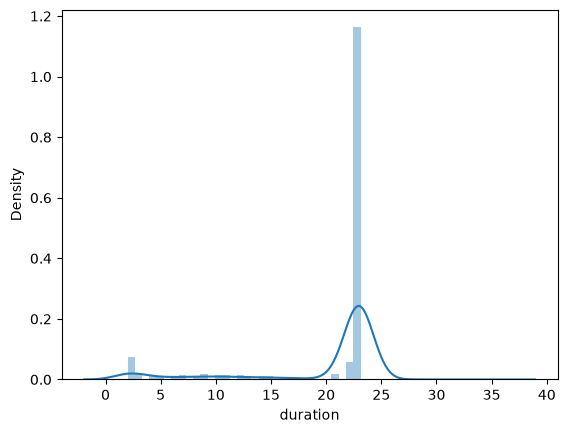

In [100]:
sns.distplot(df_jan_21.duration)

In [101]:
df_jan_21.duration.describe()

count    2632.000000
mean       20.142097
std         6.338328
min         2.000000
25%        23.000000
50%        23.000000
75%        23.000000
max        35.000000
Name: duration, dtype: float64

In [102]:
df_jan_21.duration.describe(percentiles=[0.95, 0.98, 0.99])

count    2632.000000
mean       20.142097
std         6.338328
min         2.000000
95%        23.000000
98%        23.000000
99%        23.000000
max        35.000000
Name: duration, dtype: float64

In [103]:
categorical = ['PULocationID', 'DOLocationID']

In [104]:
numerical = ['trip_distance']

In [105]:
df_jan_21[categorical] = df_jan_21[categorical].astype(str)


In [106]:
train_dict = df_jan_21[categorical + numerical].to_dict(orient='records')

In [107]:
len(train_dict)

2632

In [108]:
dv = sk.feature_extraction.DictVectorizer()

In [109]:
X_train = dv.fit_transform(train_dict)

In [110]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7896 stored elements and shape (2632, 307)>

In [111]:
target = 'duration'
y_train = df_jan_21[target].values

In [112]:
from sklearn.linear_model  import LinearRegression

In [113]:
lr = LinearRegression()

In [114]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](307,)","[ 4.92,-1.45, 1.04,..., 6.27,-6.7 ,-0.07]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,16.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,307


In [115]:
y_pred = lr.predict(X_train)

/tmp/ipykernel_5803/1351390157.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_5803/1351390157.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


<Axes: ylabel='Density'>

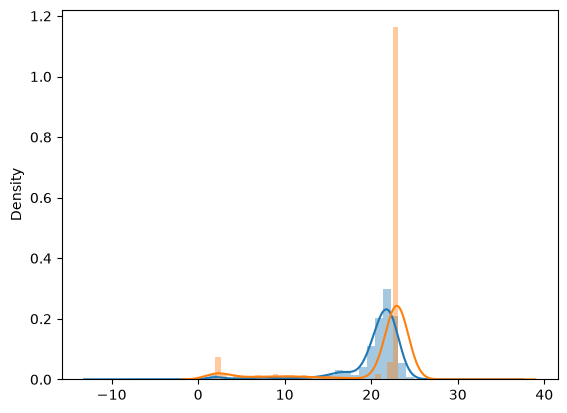

In [116]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')